### ⋆✴︎˚｡⋆ An AI model that when presented with gene expression data from skin samples, detects biomarkers for psoriasis and outputs a probability/risk score for psoriasis.  
# ------------------------------------------------------
#### Dataset used: https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE13355  
#### **GSE13355 — 122 skin samples used out of 180 total (58 PP, 58 PN, 64 NN)**
#### -PP (psoriasis) 
#### -NN (healthy) 
#### *not including PN (healthy skin from psoriasis patients) for simplicity*
#### 54,675 genes reduced to 10,923 after cleaning

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import GEOparse

print("All libraries loaded! Yay!")

All libraries loaded! Yay!


In [12]:
# gse = GEOparse.get_GEO(geo="GSE13355", destdir="./data")
# print("Download complete!")  
# ^^ used this code to get the dataframe from the ncbi GEO. Since it's already in my project files... 
df = pd.read_csv("data/cleaned_expression.csv", index_col=0)
y = pd.read_csv("data/labels.csv", index_col=0).squeeze()

print("Data loaded!")
print("Shape:", df.shape)
print("Psoriasis (1):", sum(y == 1))
print("Healthy (0):", sum(y == 0))

Data loaded!
Shape: (122, 2185)
Psoriasis (1): 58
Healthy (0): 64


In [13]:
df.head()

,1405_i_at,1431_at,1552283_s_at,1552289_a_at,1552319_a_at,1552329_at,1552365_at,1552532_a_at,1552544_at,1552619_a_at,...,37892_at,38037_at,39402_at,40524_at,41469_at,45633_at,49452_at,55081_at,60474_at,60528_at
GSM337197,-1.126897,-0.327913,0.091290,-0.071475,-1.156562,-1.124910,-0.001896,-0.422806,0.245197,-0.064556,...,1.102368,-0.347013,-0.510243,-0.233437,-2.021352,-0.237506,0.804860,-0.609398,-0.954093,-0.647693
GSM337198,0.311538,-1.041916,0.566584,0.058405,-0.529384,-0.348166,0.862287,-0.107358,0.742899,-0.439172,...,-1.128046,-0.284633,0.025017,-0.361152,-2.485609,-0.333546,0.739173,-0.627851,-0.692122,-0.217071
GSM337199,0.380125,-0.537814,0.211066,0.170119,-0.203507,0.102501,0.941907,-0.130243,1.011192,-0.012834,...,0.968729,0.159982,-0.103904,0.412757,-2.246657,-0.245240,0.395515,-0.224173,-0.082754,-0.427931
GSM337200,-0.370054,-0.842812,0.044484,0.211930,-1.070844,-0.544956,0.829396,-0.046182,-0.812636,-0.921288,...,0.013172,-0.224654,-0.309162,-0.120295,-2.296117,-0.089456,0.159905,-0.783867,-0.806824,-0.442581
GSM337201,0.489758,-0.467239,0.539163,0.320158,-0.486660,-0.360862,-0.510389,-0.822314,0.709296,-0.825643,...,0.883739,-0.619967,-0.281643,1.101854,-2.451611,-0.186698,0.162141,-0.572013,-0.396898,-0.552179


In [15]:
print("Genes before removing controls:", df.shape[1])

# remove any column that starts with AFFX, these are the controls for the researchers 
df = df.loc[:, ~df.columns.str.startswith("AFFX")]

# count after
print("Genes after removing controls:", df.shape[1])

Genes before removing controls: 2185
Genes after removing controls: 2185


In [16]:
# count before
print("Genes before removing missing values:", df.shape[1])

# drop any column that has even one missing value
df = df.dropna(axis=1)

# count after
print("Genes after removing missing values:", df.shape[1])

Genes before removing missing values: 2185
Genes after removing missing values: 2185


In [17]:
#removing genes of low variance. If a gene has same level across all samples 
#it is basically useless 

# calculate variance for every gene
gene_variances = df.var()

print("Lowest variance:", gene_variances.min().round(4))
print("Highest variance:", gene_variances.max().round(4))
print("Average variance:", gene_variances.mean().round(4))

Lowest variance: 0.3782
Highest variance: 19.3638
Average variance: 0.9034


In [18]:
#visualization is key.

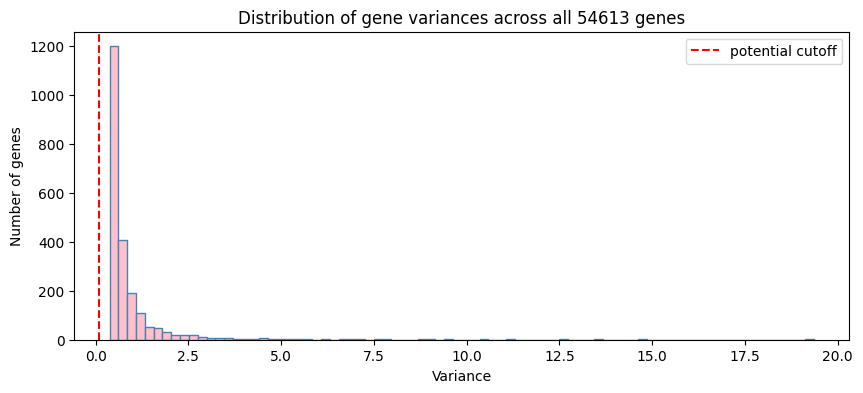

In [19]:
plt.figure(figsize=(10, 4))
plt.hist(gene_variances, bins=80, color='pink', edgecolor='steelblue')
plt.xlabel("Variance")
plt.ylabel("Number of genes")
plt.title("Distribution of gene variances across all 54613 genes")
plt.axvline(x=0.1, color='red', linestyle='--', label='potential cutoff')
plt.legend()
plt.show()

In [20]:
# calculate the 80th percentile variance cutoff (the genes that vary the least)
cutoff = gene_variances.quantile(0.80)
print("Variance cutoff:", cutoff.round(4))

# keep only genes above that cutoff
df = df.loc[:, gene_variances > cutoff]

print("Genes before:", 54613)
print("Genes after:", df.shape[1])

Variance cutoff: 1.0089
Genes before: 54613
Genes after: 437


In [21]:
# save the cleaned data table
df.to_csv("data/cleaned_expression.csv")

# save the labels
y.to_csv("data/labels.csv")

print("Saved!")
print("Data shape:", df.shape)

Saved!
Data shape: (122, 437)


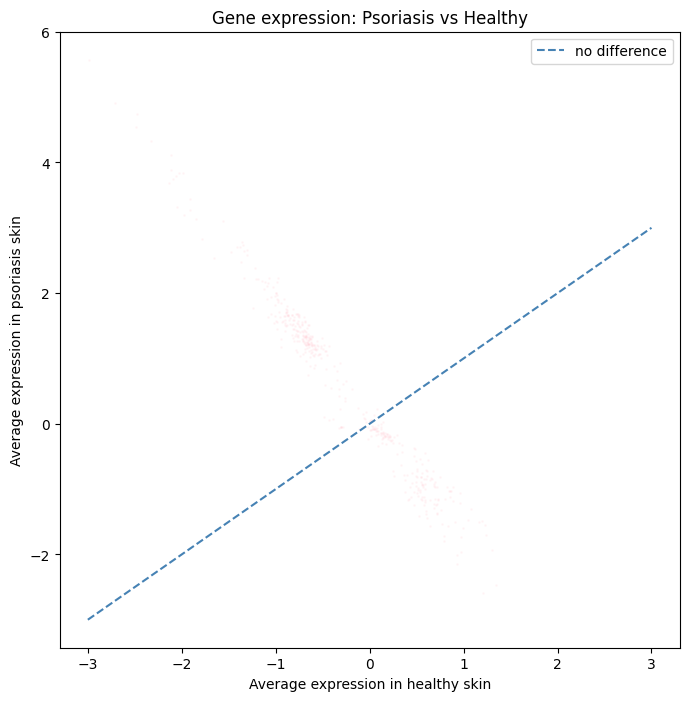

In [22]:
df_psoriasis = df[y == 1]
df_healthy = df[y == 0]
#avg expression per group
avg_psoriasis = df_psoriasis.mean()
avg_healthy = df_healthy.mean()

plt.figure(figsize=(8, 8)) 
plt.scatter(avg_healthy, avg_psoriasis, alpha=0.1, s=1, color='pink')
plt.xlabel("Average expression in healthy skin")
plt.ylabel("Average expression in psoriasis skin")
plt.title("Gene expression: Psoriasis vs Healthy")
plt.plot([-3, 3], [-3, 3], color='steelblue', linestyle='--', label='no difference')
plt.legend()
plt.show()

In [23]:
from scipy import stats

# t-test for every single gene
pvalues = {}
tstatistics = {}

for gene in df.columns:
    psoriasis_values = df_psoriasis[gene]
    healthy_values = df_healthy[gene]
    t_stat, p_val = stats.ttest_ind(psoriasis_values, healthy_values)
    pvalues[gene] = p_val
    tstatistics[gene] = t_stat

# convert to a new dataframe
results = pd.DataFrame({
    'pvalue': pvalues,
    'tstatistic': tstatistics
})

print("T-tests meaaawhjajksadj")
print("Genes tested:", len(results))
print("Genes with p < 0.05:", sum(results['pvalue'] < 0.05))

T-tests meaaawhjajksadj
Genes tested: 437
Genes with p < 0.05: 366


*bonferroni correction* is used to prevent false positives when running  
multiple tests on the same dataset 
it keeps the error rate controlled by dividing the original significance level 
by the number of tests

In [24]:
# apply Bonferroni correction 
bonferroni_cutoff = 0.05 / len(results)
print("Bonferroni cutoff:", bonferroni_cutoff)

significant_genes = results[results['pvalue'] < bonferroni_cutoff]
print("Genes after Bonferroni correction:", len(significant_genes))

# sort by most significant (smallest p-value first)
significant_genes = significant_genes.sort_values('pvalue')
print("\nTop 10 most significant genes:")
print(significant_genes.head(10))

Bonferroni cutoff: 0.00011441647597254005
Genes after Bonferroni correction: 349

Top 10 most significant genes:
                    pvalue  tstatistic
203691_at    1.467534e-113   92.768125
41469_at     5.158082e-112   90.018686
207356_at    7.737187e-109   84.615798
232170_at     1.258641e-96   66.607364
206561_s_at   5.944115e-95   64.444208
220322_at     1.130534e-83   51.498493
209720_s_at   2.696195e-82   50.094055
227735_s_at   6.775192e-82   49.692638
227736_at     8.153511e-82   49.612318
211906_s_at   9.345827e-81   48.565332


In [25]:
#still way too many freaking genes oml 
#new dataframe will include only top 300  
top_genes = significant_genes.head(300).index.tolist()
df_filtered = df[top_genes]
print("Final feature set shape:", df_filtered.shape)
print("(rows = samples, columns = selected genes)")

Final feature set shape: (122, 300)
(rows = samples, columns = selected genes)


In [26]:
df_filtered.to_csv("data/filtered_expression.csv") 
print("saved mwahaha")

saved mwahaha


### *SUMMARY OF DATA CLEANING*
- raw genes from the chip = 54675
- removed control probes (AFFX-) = 54613
- removed low variance genes = 10923
- kept only statistically significant ones = 300

Now it's time to build the model: first by splitting the data into a training set and a test set

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    df_filtered,  # our 300 genes
    y,            # our labels (0 or 1)
    test_size=0.2,        # 20% for testing
    random_state=42,      # makes the split reproducible
    stratify=y            # keeps psoriasis/healthy ratio equal in both splits
)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

Training samples: 97
Test samples: 25


In [28]:
# scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# train the model
model = LogisticRegression(
    max_iter=1000,       # gives it enough time to converge
    random_state=42
)
model.fit(X_train_scaled, y_train)

print("Model trained!")

Model trained!


In [29]:
from sklearn.metrics import classification_report, roc_auc_score

# get predictions on test set
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# print results
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Healthy', 'Psoriasis']))
print("AUROC Score:", roc_auc_score(y_test, y_prob))

Classification Report:
              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00        13
   Psoriasis       1.00      1.00      1.00        12

    accuracy                           1.00        25
   macro avg       1.00      1.00      1.00        25
weighted avg       1.00      1.00      1.00        25

AUROC Score: 1.0


In [30]:
print("AUROC Score:", round(roc_auc_score(y_test, y_prob), 4))


AUROC Score: 1.0


In [31]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
# combine scaling and model into one pipeline to prevent data leakage
#oh god pls work
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])
scores = cross_val_score(pipeline, df_filtered, y, cv=5, scoring='roc_auc')
print("AUROC per fold:", scores.round(4))
print("Average AUROC:", scores.mean().round(4))
print("Standard deviation:", scores.std().round(4))

AUROC per fold: [1. 1. 1. 1. 1.]
Average AUROC: 1.0
Standard deviation: 0.0


In [32]:
def psoriasis_risk(sample):
    #probability D:
    prob = model.predict_proba(sample)[0][1]
    

    print("Psoriasis Risk Assessment")
    print(f"Risk Score: {prob:.1%}")
    if prob >= 0.7:
        print("Risk Level: HIGH")
    elif prob >= 0.4:
        print("Risk Level: MODERATE")
    else:
        print("Risk Level: LOW")

# test it on the first test sample
psoriasis_risk(X_test_scaled[:1])
print("Actual label:", "Psoriasis" if y_test.iloc[0] == 1 else "Healthy")  

print()
print("Sample 2")
psoriasis_risk(X_test_scaled[1:2])
print("Actual:", "Psoriasis" if y_test.iloc[1] == 1 else "Healthy")

print()
print("Sample 3")
psoriasis_risk(X_test_scaled[2:3])
print("Actual:", "Psoriasis" if y_test.iloc[2] == 1 else "Healthy")

Psoriasis Risk Assessment
Risk Score: 0.0%
Risk Level: LOW
Actual label: Healthy

Sample 2
Psoriasis Risk Assessment
Risk Score: 0.1%
Risk Level: LOW
Actual: Healthy

Sample 3
Psoriasis Risk Assessment
Risk Score: 100.0%
Risk Level: HIGH
Actual: Psoriasis


*pickle* is a library used to convert complex objects into a byte steam (pickling) that can be saved to a file/database/transmitted to a network and later reconstructed back into the original object (unpickling) 

Here, it is used to save trained models as .pkl files to avoid retraining

In [33]:
#damn i didnt think that would actually work
import pickle
# save the model
with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

# save the scaler
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# save the list of top genes
with open("top_genes.pkl", "wb") as f:
    pickle.dump(top_genes, f)

print("Model saved!")
print("Scaler saved!")
print("Top genes saved!")

Model saved!
Scaler saved!
Top genes saved!


## *external validation*  
### making sure the model actually knows psoriasis with the GSE14905 dataset

In [34]:
gse2 = GEOparse.get_GEO(geo="GSE14905", destdir="./data")
print("Download complete!")

17-Jun-2026 20:15:34 DEBUG utils - Directory ./data already exists. Skipping.
17-Jun-2026 20:15:34 INFO GEOparse - File already exist: using local version.
17-Jun-2026 20:15:34 INFO GEOparse - Parsing ./data\GSE14905_family.soft.gz: 
17-Jun-2026 20:15:35 DEBUG GEOparse - DATABASE: GeoMiame
17-Jun-2026 20:15:35 DEBUG GEOparse - SERIES: GSE14905
17-Jun-2026 20:15:35 DEBUG GEOparse - PLATFORM: GPL570
C:\Users\artkm\Documents\ai-psoriasis-project\venv\Lib\site-packages\GEOparse\GEOparse.py:401: DtypeWarning: Columns (0: SPOT_ID) have mixed types. Specify dtype option on import or set low_memory=False.
  return read_csv(StringIO(data), index_col=None, sep="\t")
17-Jun-2026 20:15:39 DEBUG GEOparse - SAMPLE: GSM372286
17-Jun-2026 20:15:39 DEBUG GEOparse - SAMPLE: GSM372287
17-Jun-2026 20:15:39 DEBUG GEOparse - SAMPLE: GSM372288
17-Jun-2026 20:15:40 DEBUG GEOparse - SAMPLE: GSM372289
17-Jun-2026 20:15:40 DEBUG GEOparse - SAMPLE: GSM372290
17-Jun-2026 20:15:40 DEBUG GEOparse - SAMPLE: GSM372291

Download complete!


In [35]:
print("Number of samples:", len(gse2.gsms))

# print first 15 sample titles to see the labeling pattern
for name, sample in list(gse2.gsms.items())[15:35]:
    title = sample.metadata["title"][0]
    print(name, "→", title)

Number of samples: 82
GSM372301 → Normal Skin, Normal-16
GSM372302 → Normal Skin, Normal-17
GSM372303 → Normal Skin, Normal-18
GSM372304 → Normal Skin, Normal-19
GSM372305 → Normal Skin, Normal-20
GSM372306 → Normal Skin, Normal-21
GSM372307 → Uninvolved Skin, NS-1
GSM372308 → Lesion Skin, LS-1
GSM372309 → Uninvolved Skin, NS-2
GSM372310 → Lesion Skin, LS-2
GSM372311 → Uninvolved Skin, NS-3
GSM372312 → Lesion Skin, LS-3
GSM372313 → Uninvolved Skin, NS-4
GSM372314 → Lesion Skin, LS-4
GSM372315 → Uninvolved Skin, NS-5
GSM372316 → Lesion Skin, LS-5
GSM372317 → Uninvolved Skin, NS-6
GSM372318 → Lesion Skin, LS-6
GSM372319 → Uninvolved Skin, NS-7
GSM372320 → Lesion Skin, LS-7


In [36]:
import re

# extract the suffix after the underscore for every sample
suffixes = set()
for name, sample in gse2.gsms.items():
    title = sample.metadata["title"][0]
    suffix = title.split("_")[-1]
    suffixes.add(suffix)

print("Unique suffixes found:", suffixes)

Unique suffixes found: {'Normal Skin, Normal-11', 'Lesion Skin, LS-27', 'Uninvolved Skin, NS-18', 'Uninvolved Skin, NS-27', 'Lesion Skin, LS-31', 'Lesion Skin, LS-18', 'Normal Skin, Normal-20', 'Uninvolved Skin, NS-26', 'Lesion Skin, LS-20', 'Lesion Skin, LS-22', 'Uninvolved Skin, NS-13', 'Normal Skin, Normal-17', 'Lesion Skin, LS-19', 'Lesion Skin, LS-12', 'Lesion Skin, LS-23', 'Uninvolved Skin, NS-28', 'Lesion Skin, LS-25', 'Lesion Skin, LS-2', 'Normal Skin, Normal-4', 'Uninvolved Skin, NS-8', 'Normal Skin, Normal-12', 'Uninvolved Skin, NS-30', 'Lesion Skin, LS-3', 'Lesion Skin, LS-13', 'Normal Skin, Normal-15', 'Uninvolved Skin, NS-23', 'Lesion Skin, LS-33', 'Uninvolved Skin, NS-24', 'Uninvolved Skin, NS-16', 'Uninvolved Skin, NS-2', 'Normal Skin, Normal-3', 'Lesion Skin, LS-8', 'Lesion Skin, LS-26', 'Uninvolved Skin, NS-11', 'Uninvolved Skin, NS-7', 'Normal Skin, Normal-9', 'Lesion Skin, LS-30', 'Normal Skin, Normal-7', 'Uninvolved Skin, NS-3', 'Lesion Skin, LS-11', 'Lesion Skin, L

mwahahaha its the EXACT SAME :D

In [37]:
val_samples = {}
val_labels = {}
for name, sample in gse2.gsms.items():
    title = sample.metadata["title"][0]
    if title.startswith("Lesion Skin"):
        val_samples[name] = sample.table.set_index("ID_REF")["VALUE"]
        val_labels[name] = 1  # psoriasis
    elif title.startswith("Normal Skin"):
        val_samples[name] = sample.table.set_index("ID_REF")["VALUE"]
        val_labels[name] = 0  # healthy
df_val = pd.DataFrame(val_samples).T
y_val = pd.Series(val_labels)

print("Validation samples:", df_val.shape[0])
print("Genes per sample:", df_val.shape[1])
print("Psoriasis (1):", sum(y_val == 1))
print("Healthy (0):", sum(y_val == 0))

Validation samples: 54
Genes per sample: 54675
Psoriasis (1): 33
Healthy (0): 21


In [38]:
#checking for any overlaps between this dataset and our og one
genes_found = [g for g in top_genes if g in df_val.columns]
print("Genes found:", len(genes_found), "out of", len(top_genes))

Genes found: 300 out of 300


In [39]:
df_val_filtered = df_val[top_genes]

# scale using the SAME scaler from training (we do NOT refit it!)
X_val_scaled = scaler.transform(df_val_filtered)

# get predictions using our saved model (no retraining!)
y_val_pred = model.predict(X_val_scaled)
y_val_prob = model.predict_proba(X_val_scaled)[:, 1]

# evaluate
from sklearn.metrics import classification_report, roc_auc_score
print("Classification Report:")
print(classification_report(y_val, y_val_pred, target_names=['Healthy', 'Psoriasis'], zero_division=0))
print("AUROC:", round(roc_auc_score(y_val, y_val_prob), 4))

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.00      0.00      0.00        21
   Psoriasis       0.61      1.00      0.76        33

    accuracy                           0.61        54
   macro avg       0.31      0.50      0.38        54
weighted avg       0.37      0.61      0.46        54

AUROC: 0.9942


In [40]:
# reload our filtered training data
df_filtered = pd.read_csv("data/filtered_expression.csv", index_col=0)
print("Loaded! Shape:", df_filtered.shape)
# pick one of our top genes and compare its average value across the two datasets
gene = top_genes[0]

print(f"Gene: {gene}")
print("Average value in TRAINING data (GSE13355):", df_filtered[gene].mean().round(3))
print("Average value in VALIDATION data (GSE14905):", df_val_filtered[gene].mean().round(3))

Loaded! Shape: (122, 300)
Gene: 203691_at
Average value in TRAINING data (GSE13355): 0.86
Average value in VALIDATION data (GSE14905): 10.503


oh no D:  
The model is going through batch effect: a technical bias that happens when non-biological factors cause differences in the data. The average for the new dataset is only 10.5 because this dataset was centered around 10, and the training data was centered around 0. So, the model saw the new data was super high and assumed it was all psoriasis...

In [41]:
print("Average across ALL 300 genes:")
print("Training data (GSE13355):", df_filtered[top_genes].mean().mean().round(3))
print("Validation data (GSE14905):", df_val_filtered.mean().mean().round(3))

Average across ALL 300 genes:
Training data (GSE13355): 0.193
Validation data (GSE14905): 7.212


Here it is visible that the validation data is way higher because it isn't centered around 0 like the training data. We need to do standard scaling to the validation data: recenter around 0 and spread by standard deviation 
(x - mean)/std

In [42]:
from sklearn.preprocessing import StandardScaler

# create a NEW scaler that learns mean/std from THIS dataset's own values
val_scaler = StandardScaler()
X_val_scaled_v2 = val_scaler.fit_transform(df_val_filtered)

y_val_pred_v2 = model.predict(X_val_scaled_v2)
y_val_prob_v2 = model.predict_proba(X_val_scaled_v2)[:, 1]

print("Classification Report:")
print(classification_report(y_val, y_val_pred_v2, target_names=['Healthy', 'Psoriasis']))
print("AUROC:", round(roc_auc_score(y_val, y_val_prob_v2), 4)) 
#plsspsplsplspls

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.91      0.95      0.93        21
   Psoriasis       0.97      0.94      0.95        33

    accuracy                           0.94        54
   macro avg       0.94      0.95      0.94        54
weighted avg       0.95      0.94      0.94        54

AUROC: 0.9928


In [43]:
#get probability for each sample from validation data
for i in range(54):
    prob = y_val_prob_v2[i]
    actual = "Psoriasis" if y_val.iloc[i] == 1 else "Healthy"
    print(f"Sample {i+1}: {prob:.1%} risk → Actually {actual}")

Sample 1: 0.0% risk → Actually Healthy
Sample 2: 0.0% risk → Actually Healthy
Sample 3: 0.0% risk → Actually Healthy
Sample 4: 0.0% risk → Actually Healthy
Sample 5: 0.0% risk → Actually Healthy
Sample 6: 57.1% risk → Actually Healthy
Sample 7: 0.0% risk → Actually Healthy
Sample 8: 0.0% risk → Actually Healthy
Sample 9: 0.0% risk → Actually Healthy
Sample 10: 0.3% risk → Actually Healthy
Sample 11: 0.0% risk → Actually Healthy
Sample 12: 0.0% risk → Actually Healthy
Sample 13: 0.0% risk → Actually Healthy
Sample 14: 6.3% risk → Actually Healthy
Sample 15: 0.0% risk → Actually Healthy
Sample 16: 0.0% risk → Actually Healthy
Sample 17: 0.0% risk → Actually Healthy
Sample 18: 0.0% risk → Actually Healthy
Sample 19: 0.0% risk → Actually Healthy
Sample 20: 0.0% risk → Actually Healthy
Sample 21: 0.0% risk → Actually Healthy
Sample 22: 94.5% risk → Actually Psoriasis
Sample 23: 99.2% risk → Actually Psoriasis
Sample 24: 96.1% risk → Actually Psoriasis
Sample 25: 82.5% risk → Actually Psoria

- Sample 6: 51.6% It got confused because of the 50/50 chance   
- Sample 35: 16.0% labelled as Psoriasis 
- Sample 45: 1.5% labelled as Psoriasis


In [44]:
def get_risk_label(prob):
    if prob < 0.20:
        return "Low risk of psoriasis"
    elif prob < 0.40:
        return "Slightly elevated risk of psoriasis"
    elif prob < 0.60:
        return "Moderate risk of psoriasis — further testing recommended"
    elif prob < 0.80:
        return "High risk of psoriasis"
    else:
        return "Very high risk of psoriasis"

for i in range(54):
    prob = y_val_prob_v2[i]
    label = get_risk_label(prob)
    print(f"Sample {i+1}: {prob:.1%} — {label}")

Sample 1: 0.0% — Low risk of psoriasis
Sample 2: 0.0% — Low risk of psoriasis
Sample 3: 0.0% — Low risk of psoriasis
Sample 4: 0.0% — Low risk of psoriasis
Sample 5: 0.0% — Low risk of psoriasis
Sample 6: 57.1% — Moderate risk of psoriasis — further testing recommended
Sample 7: 0.0% — Low risk of psoriasis
Sample 8: 0.0% — Low risk of psoriasis
Sample 9: 0.0% — Low risk of psoriasis
Sample 10: 0.3% — Low risk of psoriasis
Sample 11: 0.0% — Low risk of psoriasis
Sample 12: 0.0% — Low risk of psoriasis
Sample 13: 0.0% — Low risk of psoriasis
Sample 14: 6.3% — Low risk of psoriasis
Sample 15: 0.0% — Low risk of psoriasis
Sample 16: 0.0% — Low risk of psoriasis
Sample 17: 0.0% — Low risk of psoriasis
Sample 18: 0.0% — Low risk of psoriasis
Sample 19: 0.0% — Low risk of psoriasis
Sample 20: 0.0% — Low risk of psoriasis
Sample 21: 0.0% — Low risk of psoriasis
Sample 22: 94.5% — Very high risk of psoriasis
Sample 23: 99.2% — Very high risk of psoriasis
Sample 24: 96.1% — Very high risk of ps

Right now, when the data gets scaled, a whole batch of data (in the validation dataset's case, 54 patient samples) is needed to calculate the mean and spread. The goal is that this model should be able to output a probability score with just one patient's data. Reminder that in both the training data and validation data, one sample = one skin biopsy = 300 gene expression values. 

First, take the input of the patient's 300 gene expression values, subtract their own median and apply the scaler so its on the same scale as our training data, and feed it to the model and get the probability score 

In [45]:
#testing it on sample 35

# grab sample 35 as a single row (simulating one new patient)
single_patient = df_val_filtered.iloc[[34]]  # index 34 = sample 35

# step 1: subtract the patient's own median across all 300 genes
patient_median = single_patient.median(axis=1).values[0]
single_patient_centered = single_patient - patient_median

single_patient_scaled = scaler.transform(single_patient_centered)

prob = model.predict_proba(single_patient_scaled)[0][1]
print(f"Sample 35 new score: {prob:.1%}")
print(f"Risk label: {get_risk_label(prob)}")

Sample 35 new score: 14.3%
Risk label: Low risk of psoriasis


In [46]:
def score_single(patient_data):
    patient_median = patient_data.median(axis=1).values[0]
    patient_centered = patient_data - patient_median
    patient_scaled = scaler.transform(patient_centered)
    prob = model.predict_proba(patient_scaled)[0][1]
    return prob

In [47]:
#testing it on the validation 54
for i in range(54):
    patient = df_val_filtered.iloc[[i]]
    prob = score_single(patient)
    label = get_risk_label(prob)
    actual = "Psoriasis" if y_val.iloc[i] == 1 else "Healthy"
    print(f"Sample {i+1:2d}: {prob:.1%} — {label}")

Sample  1: 0.1% — Low risk of psoriasis
Sample  2: 0.1% — Low risk of psoriasis
Sample  3: 0.1% — Low risk of psoriasis
Sample  4: 0.0% — Low risk of psoriasis
Sample  5: 0.0% — Low risk of psoriasis
Sample  6: 95.0% — Very high risk of psoriasis
Sample  7: 0.1% — Low risk of psoriasis
Sample  8: 0.1% — Low risk of psoriasis
Sample  9: 0.1% — Low risk of psoriasis
Sample 10: 12.4% — Low risk of psoriasis
Sample 11: 0.2% — Low risk of psoriasis
Sample 12: 1.1% — Low risk of psoriasis
Sample 13: 0.0% — Low risk of psoriasis
Sample 14: 14.4% — Low risk of psoriasis
Sample 15: 0.1% — Low risk of psoriasis
Sample 16: 0.1% — Low risk of psoriasis
Sample 17: 0.1% — Low risk of psoriasis
Sample 18: 1.0% — Low risk of psoriasis
Sample 19: 0.2% — Low risk of psoriasis
Sample 20: 0.0% — Low risk of psoriasis
Sample 21: 0.0% — Low risk of psoriasis
Sample 22: 93.5% — Very high risk of psoriasis
Sample 23: 99.2% — Very high risk of psoriasis
Sample 24: 99.7% — Very high risk of psoriasis
Sample 25:

In [48]:
# calculate accuracy with single patient scoring
correct = 0
for i in range(54):
    patient = df_val_filtered.iloc[[i]]
    prob = score_single(patient)
    predicted = 1 if prob >= 0.5 else 0
    actual = y_val.iloc[i]
    if predicted == actual:
        correct += 1

print(f"Correct: {correct}/54")
print(f"Accuracy: {correct/54:.1%}")

Correct: 51/54
Accuracy: 94.4%


Now the model considers each sample individually, instead of comparing it to the rest of the data presented, which is actually a better representation of the data and will work for single-patient use-cases

## Now we build the UI!

In [49]:
from flask import Flask, request, jsonify, render_template
import pandas as pd
import pickle
import numpy as np 
print("lesgo")

lesgo


Running frontend and backend on VS CODE with Flask and HTML 

In [50]:
#testing the UI with a sample from GSE30999 cuz we never used it lol 
gse3 = GEOparse.get_GEO(geo="GSE30999", destdir="./data")

# peek at one sample
sample = list(gse3.gsms.values())[0]
print("Title:", sample.metadata["title"][0])
print()
print("Data shape:", sample.table.shape)
print()
print("First 5 rows:")
print(sample.table.head())

17-Jun-2026 20:16:19 DEBUG utils - Directory ./data already exists. Skipping.
17-Jun-2026 20:16:19 INFO GEOparse - File already exist: using local version.
17-Jun-2026 20:16:19 INFO GEOparse - Parsing ./data\GSE30999_family.soft.gz: 
17-Jun-2026 20:16:19 DEBUG GEOparse - DATABASE: GeoMiame
17-Jun-2026 20:16:19 DEBUG GEOparse - SERIES: GSE30999
17-Jun-2026 20:16:19 DEBUG GEOparse - PLATFORM: GPL570
C:\Users\artkm\Documents\ai-psoriasis-project\venv\Lib\site-packages\GEOparse\GEOparse.py:401: DtypeWarning: Columns (0: SPOT_ID) have mixed types. Specify dtype option on import or set low_memory=False.
  return read_csv(StringIO(data), index_col=None, sep="\t")
17-Jun-2026 20:16:23 DEBUG GEOparse - SAMPLE: GSM767976
17-Jun-2026 20:16:23 DEBUG GEOparse - SAMPLE: GSM767977
17-Jun-2026 20:16:23 DEBUG GEOparse - SAMPLE: GSM767978
17-Jun-2026 20:16:24 DEBUG GEOparse - SAMPLE: GSM767979
17-Jun-2026 20:16:24 DEBUG GEOparse - SAMPLE: GSM767980
17-Jun-2026 20:16:24 DEBUG GEOparse - SAMPLE: GSM767981

Title: 1019-00001_NL

Data shape: (54675, 2)

First 5 rows:
           ID_REF  VALUE
0  AFFX-BioB-5_at   9.59
1  AFFX-BioB-M_at  11.12
2  AFFX-BioB-3_at  10.69
3  AFFX-BioC-5_at  11.60
4  AFFX-BioC-3_at  11.34


this dataset is identical to GSE13355

In [53]:
# finding LS sample
for name, sample in list(gse3.gsms.items())[:10]:
    title = sample.metadata["title"][0]
    print(name, "=", title)

GSM767976 = 1019-00001_NL
GSM767977 = 1019-00001_LS
GSM767978 = 1019-00013_NL
GSM767979 = 1019-00013_LS
GSM767980 = 1012-00002_NL
GSM767981 = 1012-00002_LS
GSM767982 = 2016-00013_NL
GSM767983 = 2016-00013_LS
GSM767984 = 2016-00018_NL
GSM767985 = 2016-00018_LS


In [55]:
# grab one LS sample
test_sample = gse3.gsms["GSM767977"]

# convert to the right format — genes as columns, one row
test_df = test_sample.table.set_index("ID_REF")["VALUE"].to_frame().T

print("Shape:", test_df.shape)
print("First 5 columns:")
print(test_df.iloc[:, :5])

Shape: (1, 54675)
First 5 columns:
ID_REF  AFFX-BioB-5_at  AFFX-BioB-M_at  AFFX-BioB-3_at  AFFX-BioC-5_at  \
VALUE             9.65           11.02           10.52           11.59   

ID_REF  AFFX-BioC-3_at  
VALUE            11.28  
